Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [15]:
df = pd.read_csv("labeled_data.csv")

df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Class Distribution

In [16]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


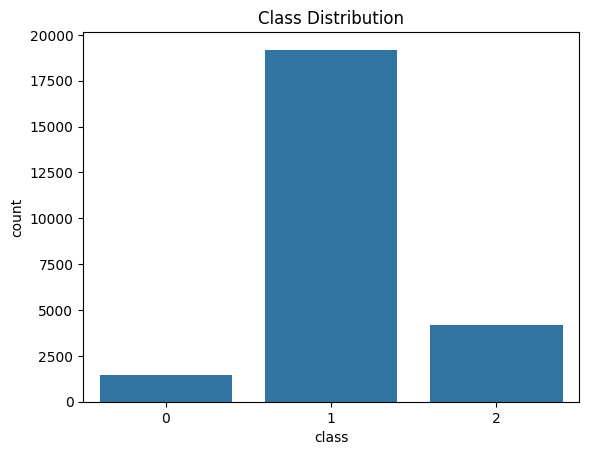

In [17]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

Text Length Analysis

In [18]:
df['length'] = df['tweet'].apply(len)

df['length'].describe()

,length
count,24783.000000
mean,85.436065
std,41.548238
min,5.000000
25%,52.000000
50%,81.000000
75%,119.000000
max,754.000000


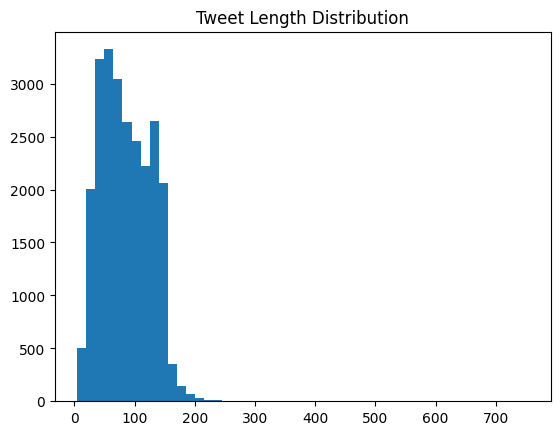

In [19]:
plt.hist(df['length'], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

Show Examples From Each Class

In [20]:
for c in df['class'].unique():
    print("\nClass:", c)
    print(df[df['class']==c]['tweet'].sample(3).values)


Class: 2
["One of the world's most prominent Jihadi forums just got shut down &#8594; http://t.co/9vafK90DOU"
 "I'll let u clam on top and let dat nookie pop I'm in dat cookie jar I ain't no rookie girllll"
 '@charlierose @jdickerson racist @NorahODonnell Texas trash GWBush came to WH numb remember he and Republicans stole the election']

Class: 1
["@mckinley719 @UberFacts Mmm no thanks I've been saving mine up for this point in time....fucking queer...."
 'RT @GrvndBxrry: i hate when bitches brag bout how they bf put it down ........ Then they single .... &#128514;'
 "@joshkline1992 that's my nig nog"]

Class: 0
['@davidly62793584 how many fuckin fags did a even get? Shouldnt be allowed into my wallet whilst under the influence haha'
 "If a spic ever talks to a white person and the white person kills them, it's self defense."
 'Niggas deserve better bitches']


Text Cleaning

In [21]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)

Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df['clean_tweet']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [23]:
pd.DataFrame(X_train).to_csv("X_train.csv")